# Key Node Phylostratigraphy

In [1]:
from collections import Counter, defaultdict
from dendropy import Tree
from tqdm.auto import tqdm
import itertools
import os
import pandas as pd
import pyham
import sys

In [2]:
fastoma_results_path = './result'

In [167]:
# load the tree and get all the branches
nwk_fn = os.path.join(fastoma_results_path, 'species_tree_checked_relabelled.nwk')
t = Tree.get(path=nwk_fn, schema='newick')

key_nodes = list(filter(lambda n: '.' not in n.label, t.internal_nodes()))
species_level_paths = defaultdict(list)
onestep_higher_paths = defaultdict(list)

for n in key_nodes:
    # get species below
    for leaf in n.leaf_nodes():
        path_len = (leaf.distance_from_root() - n.distance_from_root())
        species_level_paths[n.label].append((n.label, leaf.taxon.label, path_len))

    # find species and then get set of nodes one step higher
    for n2 in set(map(lambda n1: n1.parent_node, n.leaf_nodes())):
        if n.label != n2.label:
            path_len = (n2.distance_from_root() - n.distance_from_root())
            onestep_higher_paths[n.label].append((n.label, n2.label, path_len))

# normalise the differences in branch length between the paths
for k, v in species_level_paths.items():
    longest = max(map(lambda x: x[2], v))
    for i in range(len(v)):
        species_level_paths[k][i] = (*species_level_paths[k][i], species_level_paths[k][i][2] / longest)

for k, v in onestep_higher_paths.items():
    longest = max(map(lambda x: x[2], v))
    for i in range(len(v)):
        onestep_higher_paths[k][i] = (*onestep_higher_paths[k][i], onestep_higher_paths[k][i][2] / longest)

In [49]:
# orthoxml
ham = pyham.Ham(
            tree_file=nwk_fn,
            tree_format="newick",
            hog_file=os.path.join(fastoma_results_path, 'FastOMA_HOGs.orthoxml'),
            type_hog_file="orthoxml",
            filter_object=None,
            use_internal_name=True,
            with_parser_progress=True,
        )

Parsing Species: 0it [00:00, ?it/s]

Parsing HOGs: 0it [00:00, ?it/s]

NOTE: we only want to include SOME HOGs in our final method.

In [170]:
with open('./hogs_to_keep_no_misplaced.txt', 'rt') as fp:
    hogs_to_use = set(map(lambda x: x.rstrip(), fp.readlines()))

In [180]:
def filter_hogs(g, hogs_to_use):
    return ((not g.is_singleton()) and (g.get_top_level_hog().hog_id in hogs_to_use))

def get_count(gs):
    return sum(1 for _ in filter(lambda g: filter_hogs(g, hogs_to_use), gs))

def do(path_dict):
    for key_node_label in tqdm(path_dict):
        paths = path_dict[key_node_label]
        for i in tqdm(range(len(paths))):
            tail_genome = ham.get_ancestral_genome_by_name(paths[i][0])
            try:
                head_genome = ham.get_ancestral_genome_by_name(paths[i][1])
            except:
                head_genome = ham.get_extant_genome_by_name(paths[i][1])
            vmap = ham.compare_genomes_vertically(head_genome, tail_genome)
    
            res = {'key_node_label': key_node_label,
                   'parent_genome_name': tail_genome.name,
                   'child_genome_name': head_genome.name,
                   'retained': get_count(vmap.get_retained().keys()),
                   'gained': get_count(vmap.get_gained()),
                   'duplicated_child_count': get_count(itertools.chain.from_iterable(vmap.get_duplicated().values())),
                   'duplicated_parent_count': get_count(vmap.get_duplicated().keys()),
                   'lost': get_count(vmap.get_lost()),
                   'parent_genome_size': get_count(tail_genome.genes),
                   'child_genome_size': get_count(head_genome.genes),
                   'path_len': paths[i][2],
                   'normalised_path_len': paths[i][3]}
            yield res

In [181]:
species_level_paths_df = pd.DataFrame(do(species_level_paths))

  0%|          | 0/6 [00:00<?, ?it/s]

  0%|          | 0/45 [00:00<?, ?it/s]

  0%|          | 0/36 [00:00<?, ?it/s]

  0%|          | 0/26 [00:00<?, ?it/s]

  0%|          | 0/19 [00:00<?, ?it/s]

  0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

In [182]:
onestep_higher_paths_df = pd.DataFrame(do(onestep_higher_paths))

  0%|          | 0/6 [00:00<?, ?it/s]

  0%|          | 0/27 [00:00<?, ?it/s]

  0%|          | 0/22 [00:00<?, ?it/s]

  0%|          | 0/15 [00:00<?, ?it/s]

  0%|          | 0/11 [00:00<?, ?it/s]

  0%|          | 0/4 [00:00<?, ?it/s]

  0%|          | 0/7 [00:00<?, ?it/s]

In [183]:
tree_name = '_'.join(os.path.basename(os.getcwd()).split('_')[2:])
class_df = pd.read_csv(f'../labelled_trees/{tree_name}_colouring.tsv', sep='\t')

In [184]:
def add_child_classification(df):
    df1 = pd.merge(df, class_df, left_on='child_genome_name', right_on='id')
    header = list(df.keys())[1:]
    header = ['key_node_label', 'classification'] + header
    return df1[header].rename(columns={'classification': 'child_classification'})

In [185]:
species_level_paths_df = add_child_classification(species_level_paths_df)
onestep_higher_paths_df = add_child_classification(onestep_higher_paths_df)

In [186]:
species_level_paths_df.to_csv('results_loss_analysis/species_level_paths.tsv', sep='\t', index=False)
onestep_higher_paths_df.to_csv('results_loss_analysis/onestep_higher_paths.tsv', sep='\t', index=False)

---

In [59]:
import seaborn as sns

In [149]:
zdf = onestep_higher_paths_df[onestep_higher_paths_df.child_classification.isin({'DWR', 'SP', 'SLC', 'SLL'})]

In [150]:
zdf['retained_per'] = 100*(zdf['retained'] / zdf['parent_genome_size'])
zdf['gained_per'] = 100*(zdf['gained'] / zdf['parent_genome_size'])
zdf['duplicated_per'] = 100*(zdf['duplicated_parent_count'] / zdf['parent_genome_size'])
zdf['lost_per'] = 100*(zdf['lost'] / zdf['parent_genome_size'])

In [151]:
zdf

,key_node_label,child_classification,parent_genome_name,child_genome_name,retained,gained,duplicated_child_count,duplicated_parent_count,lost,parent_genome_size,child_genome_size,normalised_path_len,retained_per,gained_per,duplicated_per,lost_per
0,SLL_SLC_SP,SLL,SLL_SLC_SP,C.19,11885,236,801,438,1865,14188,12922,0.716892,83.767973,1.663378,3.087116,13.144911
1,SLL_SLC_SP,SLL,SLL_SLC_SP,C.26,12366,280,603,366,1456,14188,13249,0.644731,87.158162,1.973499,2.579645,10.262193
2,SLL_SLC_SP,SLL,SLL_SLC_SP,C.31,12912,177,589,317,959,14188,13678,0.501427,91.006484,1.247533,2.234282,6.759233
3,SLL_SLC_SP,SLC,SLL_SLC_SP,C.34,12614,190,697,393,1181,14188,13501,0.580405,88.906118,1.339160,2.769946,8.323936
4,SLL_SLC_SP,SLC,SLL_SLC_SP,C.36,11826,277,631,374,1988,14188,12734,0.554914,83.352129,1.952354,2.636030,14.011841
5,SLL_SLC_SP,SP,SLL_SLC_SP,C.39,12944,327,772,385,859,14188,14043,0.581004,91.232027,2.304765,2.713561,6.054412
6,SLL_SLC_SP,SLL,SLL_SLC_SP,C.30,11887,329,653,392,1909,14188,12869,0.573598,83.782069,2.318861,2.762898,13.455032
7,SLL_SLC_SP,SLC,SLL_SLC_SP,C.33,11780,269,674,393,2015,14188,12723,0.597575,83.027911,1.895968,2.769946,14.202143
8,SLL_SLC_SP,SLC,SLL_SLC_SP,C.35,12289,269,664,399,1500,14188,13222,0.614416,86.615450,1.895968,2.812236,10.572315
9,SLL_SLC_SP,SP,SLL_SLC_SP,C.42,11570,475,733,438,2180,14188,12778,1.000000,81.547787,3.347900,3.087116,15.365097


In [152]:
def do1(df):
    cols = ['retained_per', 'gained_per', 'duplicated_per', 'lost_per']
    for (_, r) in df.iterrows():
        for c in cols:
            yield (r['child_classification'], r[c], c.split('_')[0], r[c]/r['normalised_path_len'])

zdf1 = pd.DataFrame(do1(zdf), columns=['branch_group', 'per', 'event', 'normalised_per'])

In [153]:
events = ['retained', 'gained', 'duplicated', 'lost']

In [154]:
zdf1.sort_values('branch_group', inplace=True)

Text(0.5, 1.0, 'retained')

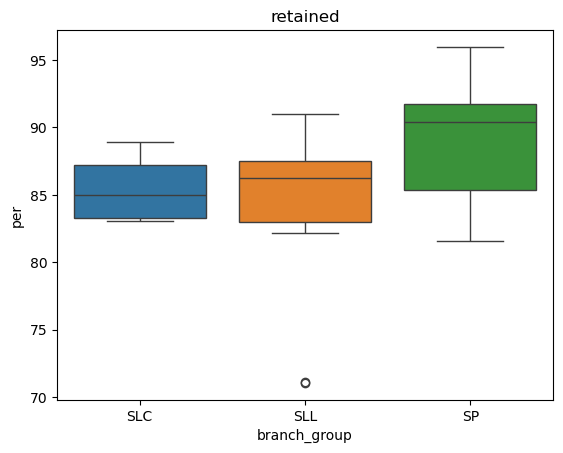

In [155]:
i = 0
ax = sns.boxplot(zdf1[zdf1.event == events[i]],
            x='branch_group',
            y='per',
            hue='branch_group')
ax.set_title(events[i])

Text(0.5, 1.0, 'gained')

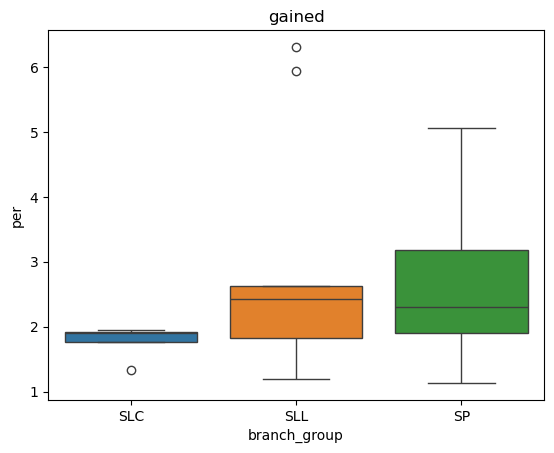

In [156]:
i = 1
ax = sns.boxplot(zdf1[zdf1.event == events[i]],
            x='branch_group',
            y='per',
            hue='branch_group')
ax.set_title(events[i])

Text(0.5, 1.0, 'duplicated')

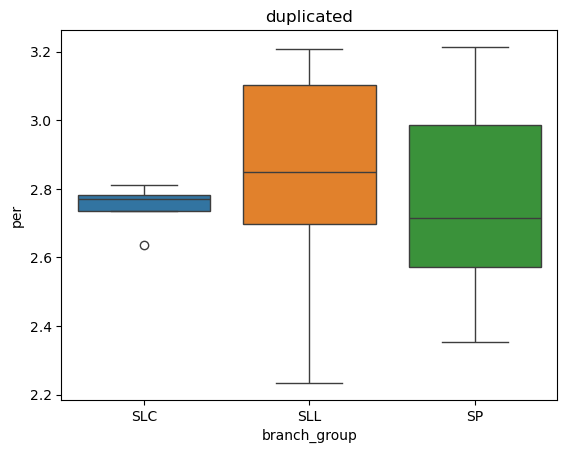

In [157]:
i = 2
ax = sns.boxplot(zdf1[zdf1.event == events[i]],
            x='branch_group',
            y='per',
            hue='branch_group')
ax.set_title(events[i])

Text(0.5, 1.0, 'lost')

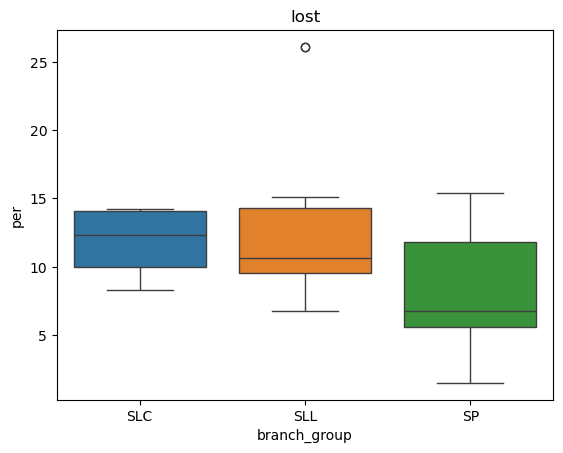

In [158]:
i = 3
ax = sns.boxplot(zdf1[zdf1.event == events[i]],
            x='branch_group',
            y='per',
            hue='branch_group')
ax.set_title(events[i])

Text(0.5, 1.0, 'retained')

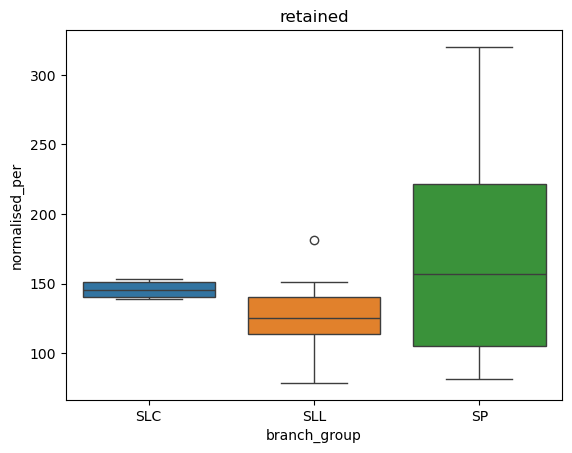

In [159]:
i = 0
ax = sns.boxplot(zdf1[zdf1.event == events[i]],
            x='branch_group',
            y='normalised_per',
            hue='branch_group')
ax.set_title(events[i])

Text(0.5, 1.0, 'gained')

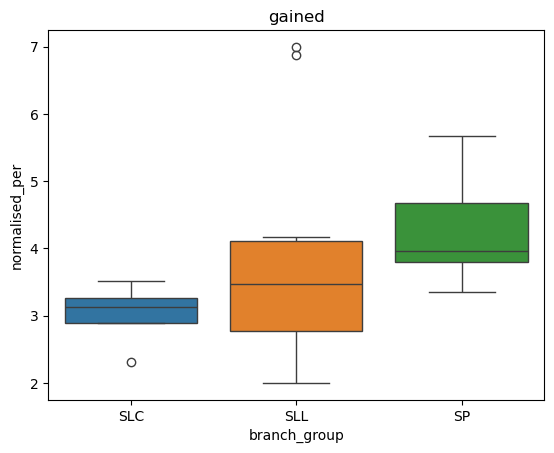

In [160]:
i = 1
ax = sns.boxplot(zdf1[zdf1.event == events[i]],
            x='branch_group',
            y='normalised_per',
            hue='branch_group')
ax.set_title(events[i])

Text(0.5, 1.0, 'duplicated')

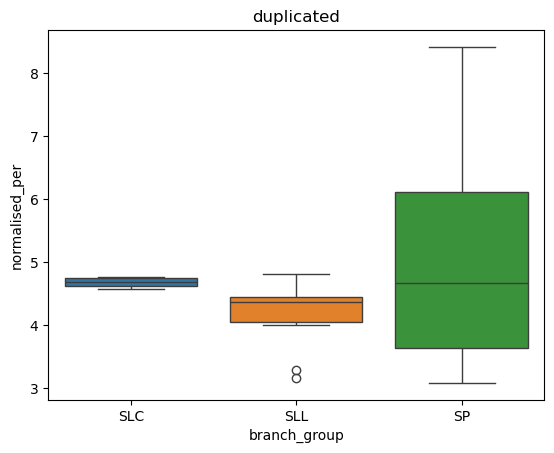

In [161]:
i = 2
ax = sns.boxplot(zdf1[zdf1.event == events[i]],
            x='branch_group',
            y='normalised_per',
            hue='branch_group')
ax.set_title(events[i])

Text(0.5, 1.0, 'lost')

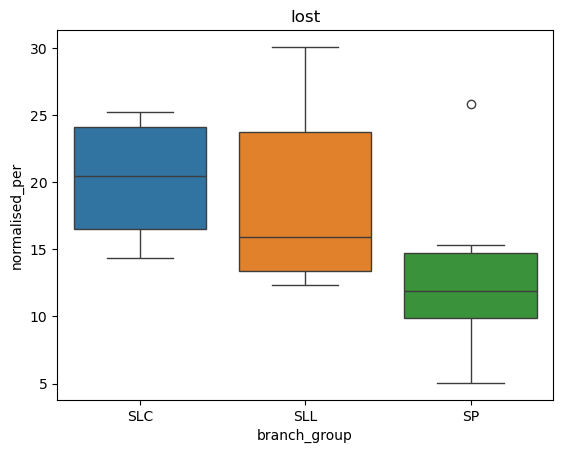

In [162]:
i = 3
ax = sns.boxplot(zdf1[zdf1.event == events[i]],
            x='branch_group',
            y='normalised_per',
            hue='branch_group')
ax.set_title(events[i])